# Chapter 2. Exponential and Mixture Families

Source orientation: printed pages 31-50, PDF pages 44-62 of *Information Geometry and Its Applications*.

This notebook is a standalone computational reading of the chapter. The central question is: when a family of probability distributions is drawn as a geometric surface, which coordinates make straight lines mean ``multiply and renormalize'', and which coordinates make straight lines mean ``average probabilities or moments''?

The visual thread has four stops:

1. Exponential families: straight in natural coordinates and governed by a convex log-partition function.
2. Mixture families: straight in expectation or probability coordinates and governed by negative entropy.
3. The simplex and Gaussian examples: the same dual geometry appears in finite distributions and continuous parametric families.
4. Projection applications: maximum entropy and mutual information become nearest-point statements for KL divergence.

## Setup

All generated files are stored below `artifacts/chapter-02/`. The helper below keeps paths book-local, so the notebook can be moved with the course folder.

In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import display, Image, HTML, Markdown

ARTIFACT_DIR = Path('artifacts/chapter-02')
FIG_DIR = ARTIFACT_DIR / 'figures'
HTML_DIR = ARTIFACT_DIR / 'html'
TABLE_DIR = ARTIFACT_DIR / 'tables'
CHECK_DIR = ARTIFACT_DIR / 'checks'
for folder in [FIG_DIR, HTML_DIR, TABLE_DIR, CHECK_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

EPS = 1e-12

def softmax_from_theta(theta):
    theta = np.asarray(theta, dtype=float)
    logits = np.r_[0.0, theta]
    z = logits - logits.max()
    p = np.exp(z)
    return p / p.sum()

def theta_from_simplex(p):
    p = np.asarray(p, dtype=float)
    return np.log(p[1:] / p[0])

def neg_entropy(p):
    p = np.asarray(p, dtype=float)
    return float(np.sum(p * np.log(np.clip(p, EPS, None))))

def entropy(p):
    return -neg_entropy(p)

def kl(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    return float(np.sum(p * (np.log(np.clip(p, EPS, None)) - np.log(np.clip(q, EPS, None)))))

def bregman_psi(theta_a, theta_b):
    theta_a = np.asarray(theta_a, dtype=float)
    theta_b = np.asarray(theta_b, dtype=float)
    psi = lambda th: math.log1p(np.exp(th[0]) + np.exp(th[1]))
    eta_b = softmax_from_theta(theta_b)[1:]
    return float(psi(theta_a) - psi(theta_b) - eta_b @ (theta_a - theta_b))

def barycentric_to_xy(p):
    p = np.asarray(p, dtype=float)
    vertices = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, np.sqrt(3)/2]])
    return p @ vertices

def savefig(path):
    plt.savefig(path, dpi=180, bbox_inches='tight')
    plt.close()
    return path

def display_artifact(path, kind=None):
    path = Path(path)
    if kind == 'html' or path.suffix.lower() == '.html':
        display(HTML(f'<a href="{path.as_posix()}" target="_blank">{path.as_posix()}</a>'))
    elif path.suffix.lower() in {'.png', '.jpg', '.jpeg'}:
        display(Image(filename=str(path)))
    elif path.suffix.lower() == '.csv':
        display(pd.read_csv(path))
    elif path.suffix.lower() == '.json':
        display(json.loads(path.read_text()))
    else:
        display(Markdown(f'`{path.as_posix()}`'))

## 1. Translation Guide: The Same Distribution Has Two Honest Coordinate Systems

An exponential family writes a density in the form

\[
p(x,\theta) = \exp(\theta \cdot x - \psi(\theta))
\]

with respect to a chosen base measure. The function \(\psi\) normalizes the density, and its gradient returns expectation coordinates:

\[
\eta = \nabla \psi(\theta) = E_\theta[x].
\]

The Legendre dual \(\phi(\eta)=\theta\cdot\eta-\psi(\theta)\) is negative entropy when \(\eta\) comes from the matching distribution. This is why information geometry treats \(\theta\) and \(\eta\) as paired affine coordinates rather than as two unrelated parameterizations.

For a mixture family, the model starts from averaging component densities. The coordinates \(\eta\) are primary because a straight line in \(\eta\) is literally a mixture inside the family. The dual coordinates \(\theta=\nabla\phi(\eta)\) still exist, but they need not be natural parameters of an exponential family.

In [2]:
rows = [
    {'object': 'exponential family', 'straight coordinate': 'theta', 'straight curve means': 'linear interpolation of log densities, then renormalize', 'convex potential': 'psi(theta) = log integral exp(theta dot x) dmu'},
    {'object': 'mixture family', 'straight coordinate': 'eta', 'straight curve means': 'linear interpolation of probabilities or moments', 'convex potential': 'phi(eta) = integral p_eta log p_eta'},
    {'object': 'probability simplex S_n', 'straight coordinate': 'both, dually', 'straight curve means': 'e-curves are log-linear; m-curves are ordinary mixtures', 'convex potential': 'log-sum-exp / negative entropy'},
    {'object': 'Gaussian family', 'straight coordinate': 'theta=(mu/sigma^2, -1/(2 sigma^2))', 'straight curve means': 'log-quadratic interpolation', 'convex potential': 'Gaussian log-partition'},
]
translation_table = pd.DataFrame(rows)
translation_path = TABLE_DIR / 'coordinate_translation_guide.csv'
translation_table.to_csv(translation_path, index=False)
display_artifact(translation_path)

,object,straight coordinate,straight curve means,convex potential
0,exponential family,theta,"linear interpolation of log densities, then re...",psi(theta) = log integral exp(theta dot x) dmu
1,mixture family,eta,linear interpolation of probabilities or moments,phi(eta) = integral p_eta log p_eta
2,probability simplex S_n,"both, dually",e-curves are log-linear; m-curves are ordinary...,log-sum-exp / negative entropy
3,Gaussian family,"theta=(mu/sigma^2, -1/(2 sigma^2))",log-quadratic interpolation,Gaussian log-partition


## 2. The Simplex: e-Geodesics Bend Where m-Geodesics Are Straight

The three-outcome simplex is the smallest picture where both geometries can be seen at once. An m-geodesic between two distributions is the ordinary segment

\[
p_m(t)=(1-t)p_0+t p_1.
\]

An e-geodesic is straight in natural coordinates \(\theta_i=\log(p_i/p_0)\):

\[
\theta_e(t)=(1-t)\theta(p_0)+t\theta(p_1), \qquad p_e(t)=\operatorname{softmax}(0,\theta_e(t)).
\]

In the Euclidean drawing of the triangle, the m-geodesic is visually straight. The e-geodesic usually curves because the drawing uses probability coordinates, not log-odds coordinates.

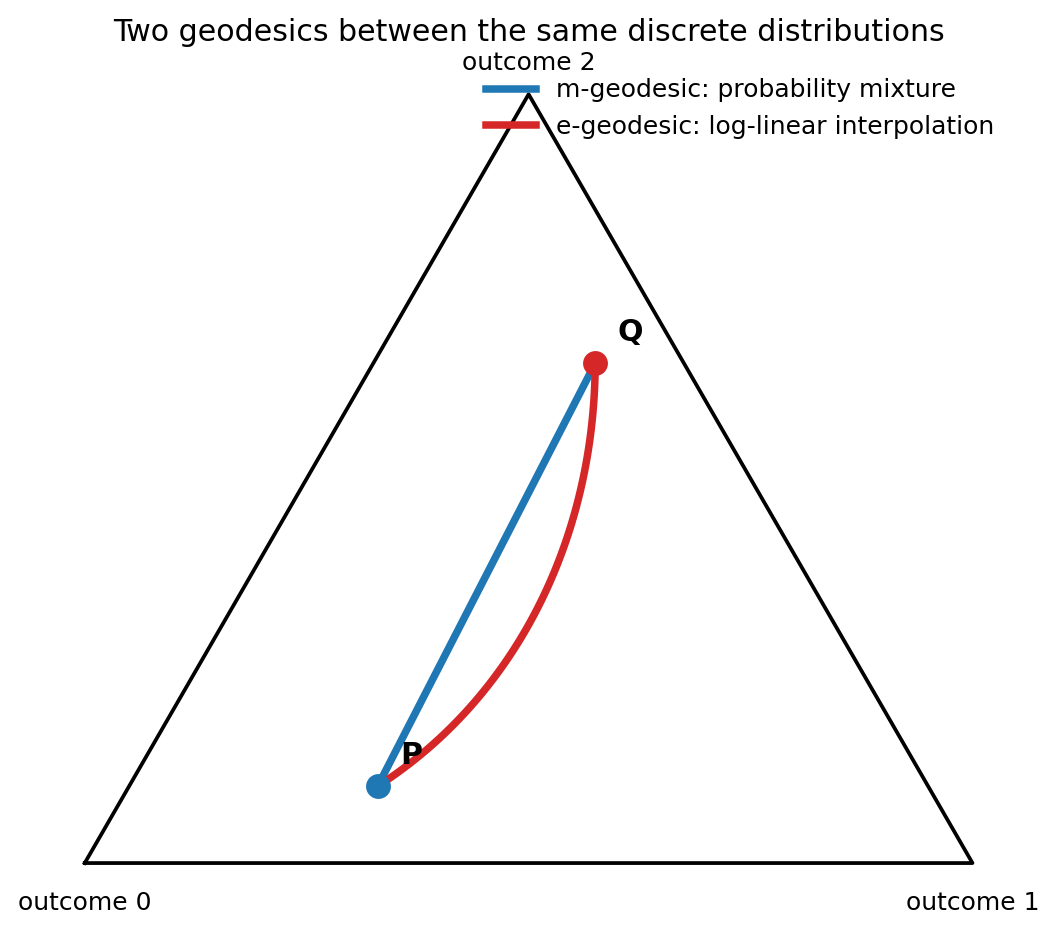

In [3]:
p_a = np.array([0.62, 0.28, 0.10])
p_b = np.array([0.10, 0.25, 0.65])
ts = np.linspace(0, 1, 101)
m_path = np.array([(1-t)*p_a + t*p_b for t in ts])
th_a, th_b = theta_from_simplex(p_a), theta_from_simplex(p_b)
e_path = np.array([softmax_from_theta((1-t)*th_a + t*th_b) for t in ts])

fig, ax = plt.subplots(figsize=(7.0, 6.2))
tri = np.array([[0,0],[1,0],[0.5,np.sqrt(3)/2],[0,0]])
ax.plot(tri[:,0], tri[:,1], color='black', lw=1.5)
for label, p in [('outcome 0', [1,0,0]), ('outcome 1', [0,1,0]), ('outcome 2', [0,0,1])]:
    x, y = barycentric_to_xy(p)
    ax.text(x, y-0.045 if y == 0 else y+0.035, label, ha='center', va='center', fontsize=10)
xy_m = np.array([barycentric_to_xy(p) for p in m_path])
xy_e = np.array([barycentric_to_xy(p) for p in e_path])
ax.plot(xy_m[:,0], xy_m[:,1], color='#1f77b4', lw=3, label='m-geodesic: probability mixture')
ax.plot(xy_e[:,0], xy_e[:,1], color='#d62728', lw=3, label='e-geodesic: log-linear interpolation')
for name, p, color in [('P', p_a, '#1f77b4'), ('Q', p_b, '#d62728')]:
    x, y = barycentric_to_xy(p)
    ax.scatter([x], [y], s=80, color=color, zorder=3)
    ax.text(x+0.025, y+0.025, name, fontsize=12, weight='bold')
ax.set_title('Two geodesics between the same discrete distributions')
ax.set_aspect('equal')
ax.axis('off')
ax.legend(loc='upper right', frameon=False)
simplex_path = FIG_DIR / 'simplex_e_vs_m_geodesics.png'
savefig(simplex_path)
display_artifact(simplex_path)

In [ ]:
mesh = []
grid = np.linspace(0.02, 0.96, 48)
for p1 in grid:
    for p2 in grid:
        p0 = 1 - p1 - p2
        if p0 > 0.02:
            p = np.array([p0, p1, p2])
            x, y = barycentric_to_xy(p)
            mesh.append({'p0':p0, 'p1':p1, 'p2':p2, 'x':x, 'y':y, 'negative_entropy':neg_entropy(p), 'entropy':entropy(p)})
mesh_df = pd.DataFrame(mesh)
fig = px.scatter(mesh_df, x='x', y='y', color='entropy', hover_data=['p0','p1','p2','negative_entropy'],
                 color_continuous_scale='Viridis', title='Entropy landscape on the 3-outcome simplex')
fig.update_traces(marker={'size':7})
fig.update_yaxes(scaleanchor='x', scaleratio=1, visible=False)
fig.update_xaxes(visible=False)
fig.update_layout(width=760, height=620, margin=dict(l=20, r=20, t=60, b=20))
simplex_html = HTML_DIR / 'simplex_entropy_landscape.html'
fig.write_html(simplex_html, include_plotlyjs=True)
display_artifact(simplex_html, 'html')

## 3. Log-Partition, KL, and Fisher Information in the Discrete Case

For the simplex with baseline outcome 0,

\[
\psi(\theta)=\log(1+e^{\theta_1}+e^{\theta_2}), \qquad
\eta_i=\partial_i\psi(\theta)=p_i.
\]

The Hessian of \(\psi\) is the covariance matrix of the sufficient statistics. It is also the Fisher information matrix in natural coordinates. The Bregman divergence induced by \(\psi\) matches KL divergence, with the argument order fixed by the convention used in the chapter.

In [5]:
def fisher_simplex(theta):
    p = softmax_from_theta(theta)
    eta = p[1:]
    return np.diag(eta) - np.outer(eta, eta)

sample_theta = np.array([0.45, -0.35])
sample_p = softmax_from_theta(sample_theta)
G = fisher_simplex(sample_theta)
finite_h = 1e-4
psi = lambda th: math.log1p(np.exp(th[0]) + np.exp(th[1]))
H_fd = np.zeros((2,2))
for i in range(2):
    for j in range(2):
        ei = np.eye(2)[i]
        ej = np.eye(2)[j]
        H_fd[i,j] = (psi(sample_theta+finite_h*ei+finite_h*ej) - psi(sample_theta+finite_h*ei-finite_h*ej) - psi(sample_theta-finite_h*ei+finite_h*ej) + psi(sample_theta-finite_h*ei-finite_h*ej))/(4*finite_h**2)

metric_table = pd.DataFrame(G, columns=['theta1 direction','theta2 direction'], index=['theta1 score','theta2 score'])
metric_path = TABLE_DIR / 'simplex_fisher_metric.csv'
metric_table.to_csv(metric_path)
print('sample p =', sample_p)
print('Fisher / Hessian matrix:')
display(metric_table)
print('finite-difference Hessian max error:', np.max(np.abs(G-H_fd)))

sample p = [0.30553007 0.47916653 0.2153034 ]
Fisher / Hessian matrix:


,theta1 direction,theta2 direction
theta1 score,0.249566,-0.103166
theta2 score,-0.103166,0.168948


finite-difference Hessian max error: 3.811782889329152e-09


## 4. Gaussian Coordinates: One Curve, Two Coordinate Shadows

The one-dimensional Gaussian family is an exponential family with sufficient statistics \((x,x^2)\). The natural and expectation coordinates are

\[
\theta_1=\frac{\mu}{\sigma^2}, \qquad
\theta_2=-\frac{1}{2\sigma^2}, \qquad
\eta_1=\mu, \qquad
\eta_2=\mu^2+\sigma^2.
\]

The constraint \(\eta_2>\eta_1^2\) says that variance is positive. Natural coordinates occupy the half-plane \(\theta_2<0\). The map between them is nonlinear, so a regular grid in one coordinate system becomes curved in the other.

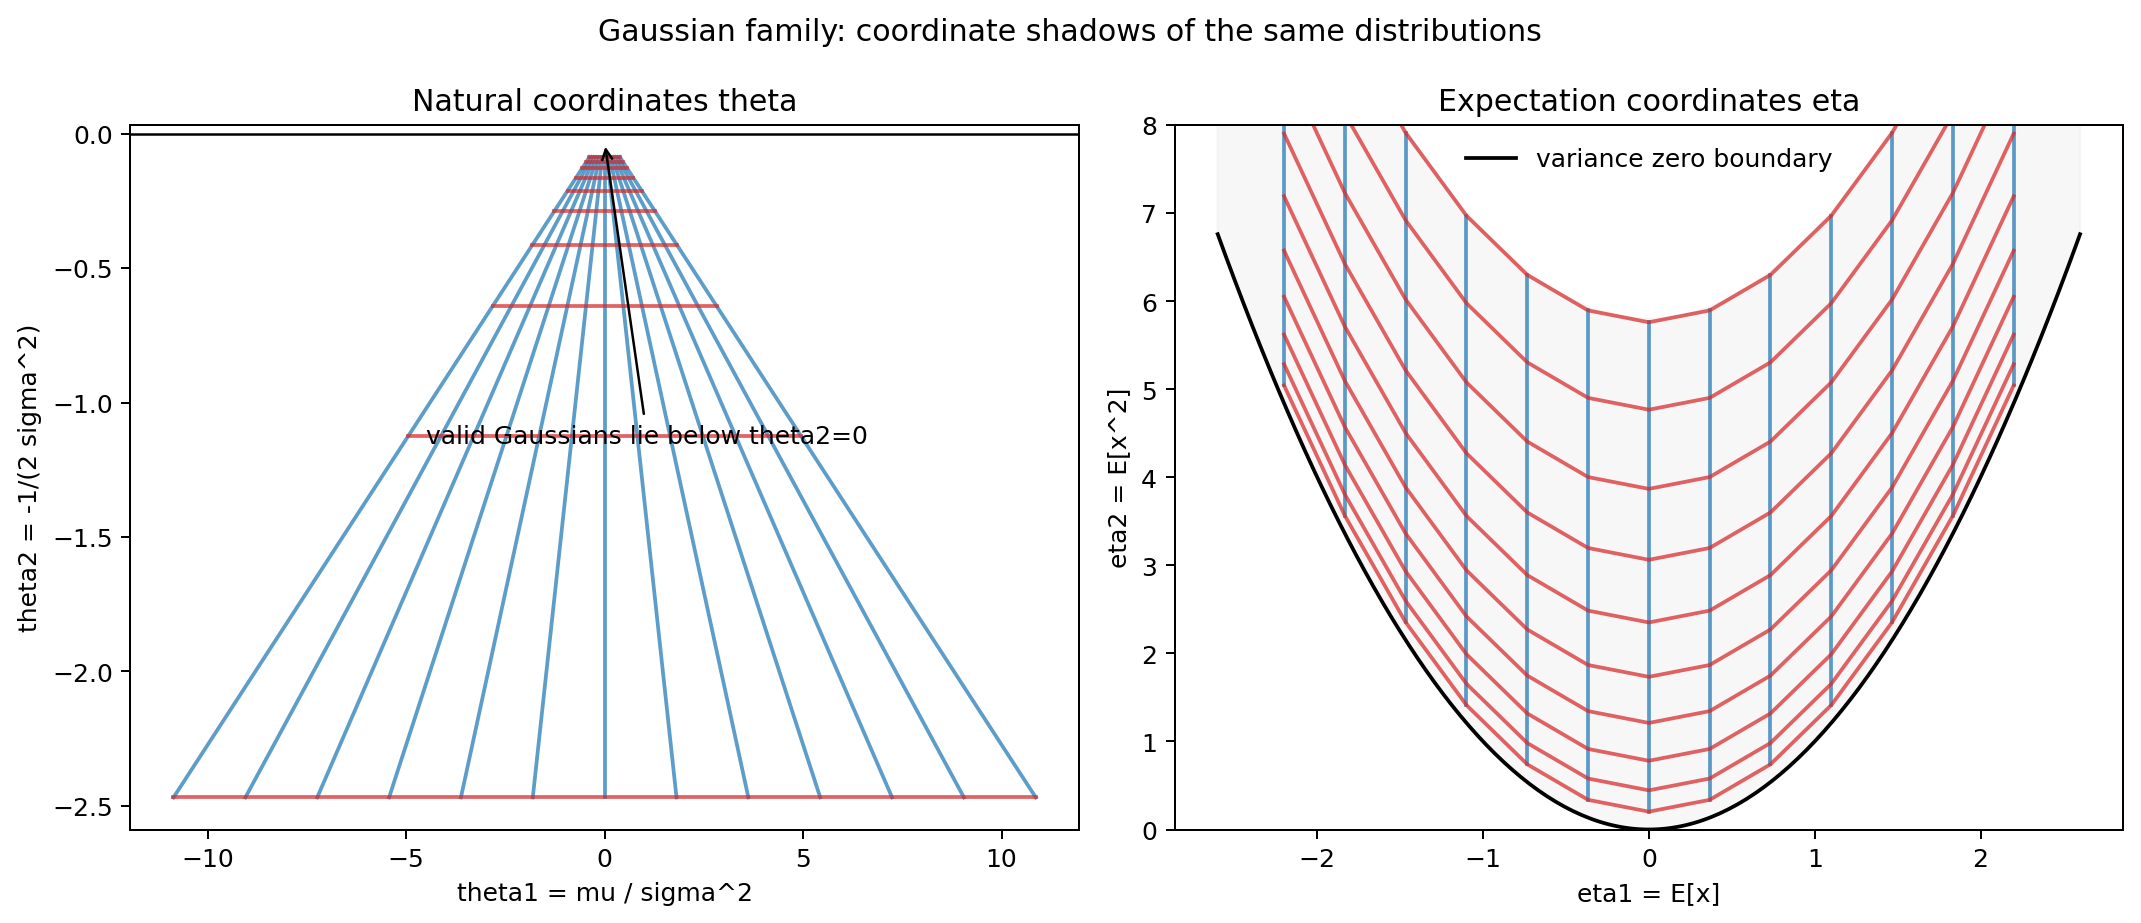

In [6]:
mu_vals = np.linspace(-2.2, 2.2, 13)
sigma_vals = np.linspace(0.45, 2.4, 10)
curves_mu = []
curves_sig = []
for mu in mu_vals:
    pts = []
    for sig in sigma_vals:
        theta1 = mu / sig**2
        theta2 = -1/(2*sig**2)
        eta1 = mu
        eta2 = mu**2 + sig**2
        pts.append((theta1, theta2, eta1, eta2))
    curves_mu.append(np.array(pts))
for sig in sigma_vals:
    pts = []
    for mu in mu_vals:
        theta1 = mu / sig**2
        theta2 = -1/(2*sig**2)
        eta1 = mu
        eta2 = mu**2 + sig**2
        pts.append((theta1, theta2, eta1, eta2))
    curves_sig.append(np.array(pts))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for pts in curves_mu:
    axes[0].plot(pts[:,0], pts[:,1], color='#1f77b4', alpha=0.72)
for pts in curves_sig:
    axes[0].plot(pts[:,0], pts[:,1], color='#d62728', alpha=0.72)
axes[0].set_title('Natural coordinates theta')
axes[0].set_xlabel('theta1 = mu / sigma^2')
axes[0].set_ylabel('theta2 = -1/(2 sigma^2)')
axes[0].axhline(0, color='black', lw=1)
axes[0].annotate('valid Gaussians lie below theta2=0', xy=(0, -0.03), xytext=(-4.5, -1.15), arrowprops={'arrowstyle':'->'})
for pts in curves_mu:
    axes[1].plot(pts[:,2], pts[:,3], color='#1f77b4', alpha=0.72)
for pts in curves_sig:
    axes[1].plot(pts[:,2], pts[:,3], color='#d62728', alpha=0.72)
eta1 = np.linspace(-2.6, 2.6, 200)
axes[1].plot(eta1, eta1**2, color='black', lw=1.5, label='variance zero boundary')
axes[1].fill_between(eta1, eta1**2, eta1**2 + 5.8, color='#eeeeee', alpha=0.45)
axes[1].set_ylim(0, 8)
axes[1].set_title('Expectation coordinates eta')
axes[1].set_xlabel('eta1 = E[x]')
axes[1].set_ylabel('eta2 = E[x^2]')
axes[1].legend(frameon=False)
fig.suptitle('Gaussian family: coordinate shadows of the same distributions')
fig.tight_layout()
gaussian_path = FIG_DIR / 'gaussian_theta_eta_coordinate_grids.png'
savefig(gaussian_path)
display_artifact(gaussian_path)

## 5. Maximum Entropy as Projection

Suppose a discrete distribution on states \(x\) is constrained by one expected value, \(E[x]=a\). The feasible set is m-flat because mixing two distributions with the same expectation preserves that expectation. The maximum-entropy member is the e-projection of the uniform distribution onto that m-flat slice, and has exponential form

\[
\hat p_\lambda(x)=\frac{\exp(\lambda x)}{\sum_z \exp(\lambda z)}.
\]

The plot below shows the entropy along the feasible line for a three-state example. The maximum occurs exactly where the exponential-family member with the requested mean intersects the mixture constraint.

lambda = 0.5511899971526228
p_hat = [0.17401469 0.30197062 0.52401469] mean = 1.35 entropy = 1.0045090573427984


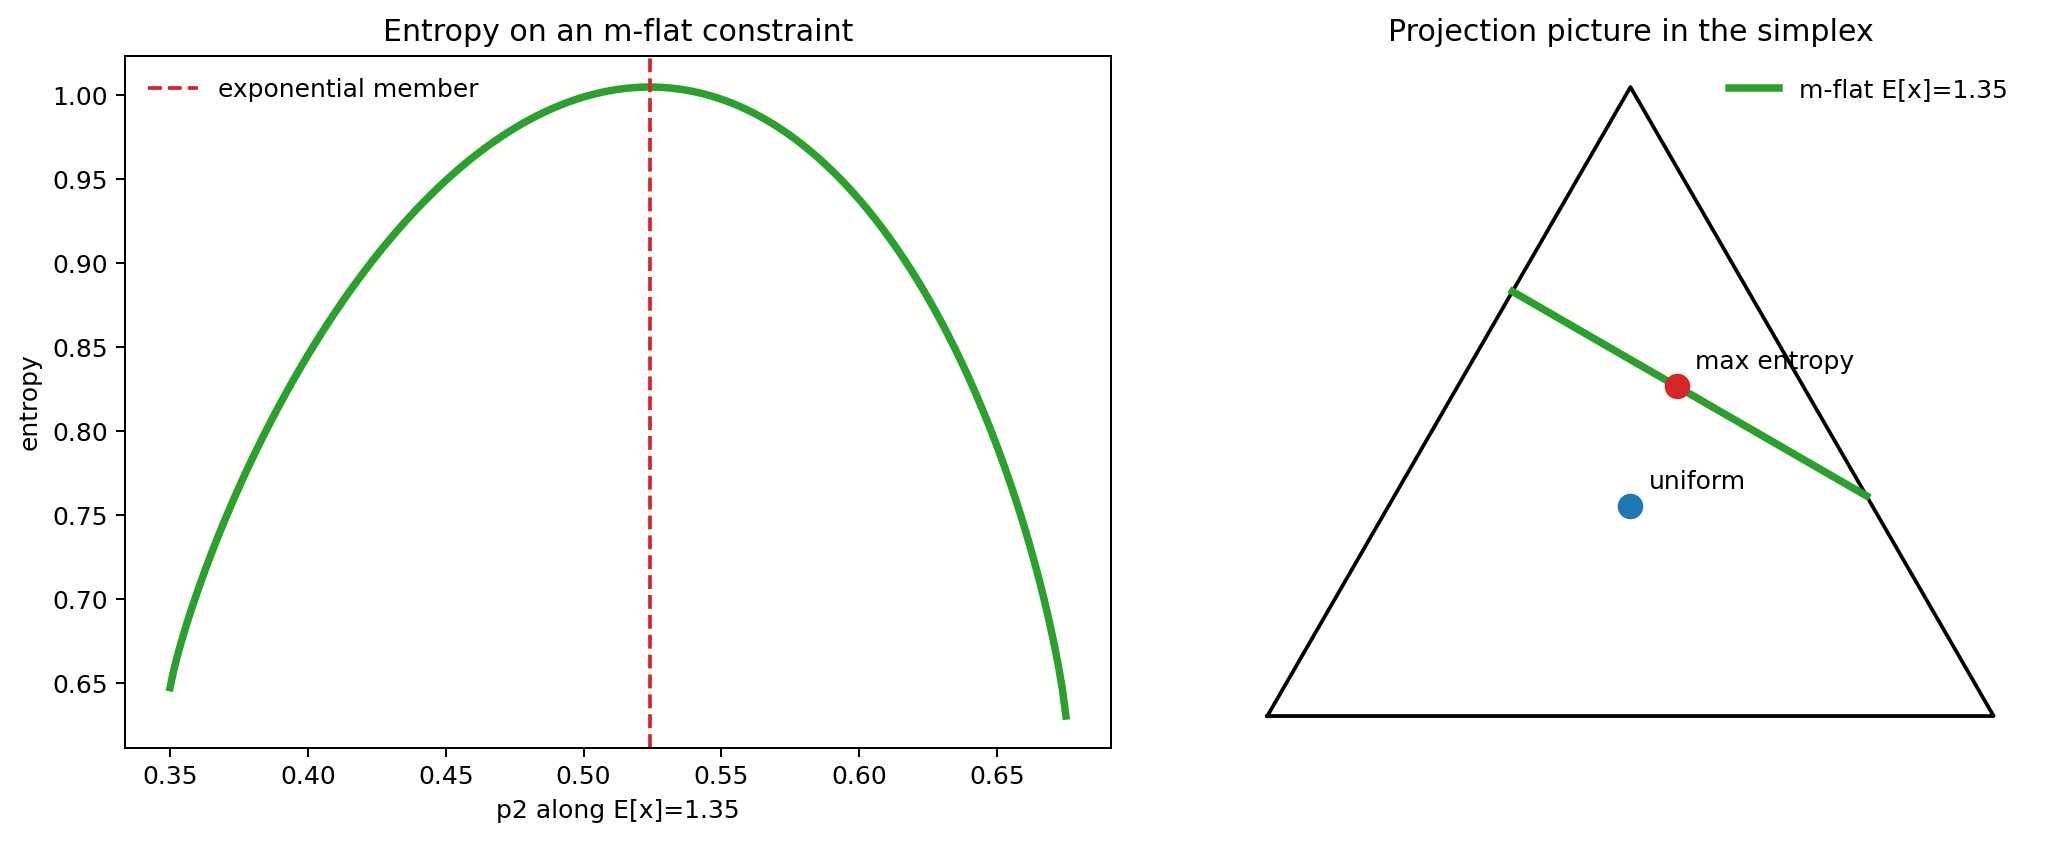

In [7]:
states = np.array([0.0, 1.0, 2.0])
target_mean = 1.35
# Feasible p=(p0,p1,p2) with p1+2p2=target_mean and sum p=1.
p2_values = np.linspace(max(0, target_mean-1), min(target_mean/2, 1), 250)
feasible = []
for p2 in p2_values:
    p1 = target_mean - 2*p2
    p0 = 1 - p1 - p2
    if min(p0, p1, p2) >= -1e-10:
        p = np.array([p0, p1, p2])
        feasible.append({'p0':p0, 'p1':p1, 'p2':p2, 'entropy':entropy(p)})
feasible_df = pd.DataFrame(feasible)

# Solve mean(lambda)=target_mean by bisection.
lo, hi = -20.0, 20.0
for _ in range(120):
    mid = (lo + hi)/2
    w = np.exp(mid * states)
    p_mid = w/w.sum()
    if p_mid @ states < target_mean:
        lo = mid
    else:
        hi = mid
lam = (lo + hi)/2
w = np.exp(lam * states)
p_hat = w / w.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].plot(feasible_df['p2'], feasible_df['entropy'], color='#2ca02c', lw=3)
axes[0].axvline(p_hat[2], color='#d62728', ls='--', label='exponential member')
axes[0].set_xlabel('p2 along E[x]=1.35')
axes[0].set_ylabel('entropy')
axes[0].set_title('Entropy on an m-flat constraint')
axes[0].legend(frameon=False)
tri = np.array([[0,0],[1,0],[0.5,np.sqrt(3)/2],[0,0]])
axes[1].plot(tri[:,0], tri[:,1], color='black')
xy_feas = np.array([barycentric_to_xy([r.p0, r.p1, r.p2]) for r in feasible_df.itertuples()])
axes[1].plot(xy_feas[:,0], xy_feas[:,1], color='#2ca02c', lw=3, label='m-flat E[x]=1.35')
uniform = np.ones(3)/3
for label, p, color in [('uniform', uniform, '#1f77b4'), ('max entropy', p_hat, '#d62728')]:
    x, y = barycentric_to_xy(p)
    axes[1].scatter([x], [y], s=85, color=color, zorder=3)
    axes[1].text(x+0.025, y+0.025, label, fontsize=10)
axes[1].set_aspect('equal')
axes[1].axis('off')
axes[1].legend(frameon=False, loc='upper right')
axes[1].set_title('Projection picture in the simplex')
fig.tight_layout()
maxent_path = FIG_DIR / 'maximum_entropy_projection.png'
savefig(maxent_path)
print('lambda =', lam)
print('p_hat =', p_hat, 'mean =', p_hat @ states, 'entropy =', entropy(p_hat))
display_artifact(maxent_path)

## 6. Mutual Information as Distance from Independence

For a joint distribution \(p(x,y)\), the independent family consists of products \(p_X(x)p_Y(y)\). It is e-flat: multiplying two product distributions along an e-geodesic and renormalizing remains a product distribution. The m-projection of any joint distribution onto this family preserves both marginals, so the projected point is

\[
\hat p(x,y)=p_X(x)p_Y(y).
\]

The KL divergence \(D_{KL}(p: p_Xp_Y)\) is mutual information. In other words, mutual information is the information-geometric distance from independence.

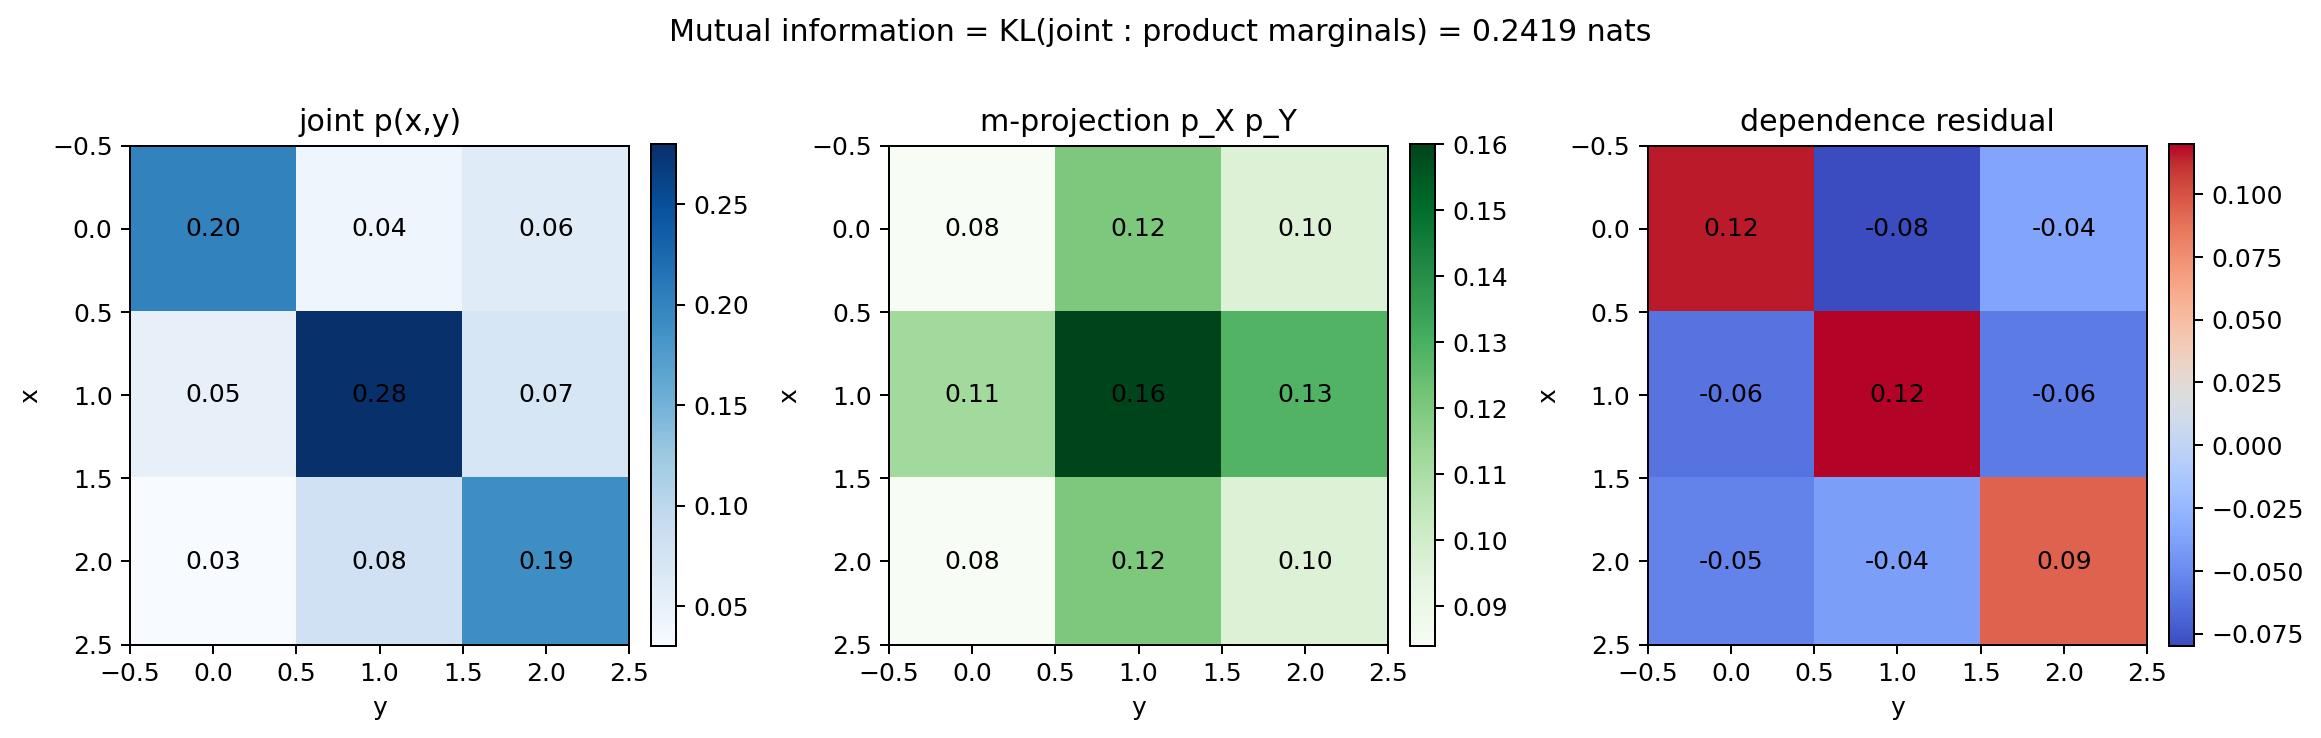

In [8]:
joint = np.array([
    [0.20, 0.04, 0.06],
    [0.05, 0.28, 0.07],
    [0.03, 0.08, 0.19],
], dtype=float)
joint = joint / joint.sum()
px = joint.sum(axis=1)
py = joint.sum(axis=0)
prod = np.outer(px, py)
mi = kl(joint.ravel(), prod.ravel())

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
vmax = max(joint.max(), prod.max(), np.abs(joint-prod).max())
images = [joint, prod, joint-prod]
titles = ['joint p(x,y)', 'm-projection p_X p_Y', 'dependence residual']
cmaps = ['Blues', 'Greens', 'coolwarm']
for ax, data, title, cmap in zip(axes, images, titles, cmaps):
    im = ax.imshow(data, cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel('y')
    ax.set_ylabel('x')
    for (i, j), val in np.ndenumerate(data):
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f'Mutual information = KL(joint : product marginals) = {mi:.4f} nats')
fig.tight_layout()
mi_path = FIG_DIR / 'mutual_information_projection.png'
savefig(mi_path)

df_mi = pd.DataFrame(joint, columns=[f'y{j}' for j in range(joint.shape[1])], index=[f'x{i}' for i in range(joint.shape[0])])
mi_table_path = TABLE_DIR / 'mutual_information_joint_distribution.csv'
df_mi.to_csv(mi_table_path)
display_artifact(mi_path)

In [ ]:
# Interactive surface: change a 2x2 odds ratio while keeping the display compact.
rs = np.linspace(-2.2, 2.2, 80)
qs = np.linspace(0.12, 0.88, 70)
rows = []
for r in rs:
    odds = math.exp(r)
    for q in qs:
        # Symmetric binary joint with diagonal mass q split evenly and off-diagonal mass 1-q split evenly.
        p = np.array([[q/2, (1-q)/2], [(1-q)/2, q/2]])
        # Tilt toward the requested log odds ratio by mixing in the odds-ratio family.
        a = odds / (2*(1+odds))
        p_or = np.array([[a, 0.5-a], [0.5-a, a]])
        p_mix = 0.55*p + 0.45*p_or
        prod_binary = np.outer(p_mix.sum(axis=1), p_mix.sum(axis=0))
        rows.append({'log_odds_ratio_control':r, 'diagonal_mass_control':q, 'mutual_information':kl(p_mix.ravel(), prod_binary.ravel())})
mi_surface = pd.DataFrame(rows)
fig = go.Figure(data=[go.Surface(
    x=mi_surface['log_odds_ratio_control'].to_numpy().reshape(len(rs), len(qs)),
    y=mi_surface['diagonal_mass_control'].to_numpy().reshape(len(rs), len(qs)),
    z=mi_surface['mutual_information'].to_numpy().reshape(len(rs), len(qs)),
    colorscale='Viridis')])
fig.update_layout(title='Binary mutual information surface', scene=dict(xaxis_title='log odds-ratio control', yaxis_title='diagonal mass control', zaxis_title='MI (nats)'), width=800, height=650)
mi_html = HTML_DIR / 'mutual_information_surface.html'
fig.write_html(mi_html, include_plotlyjs=True)
display_artifact(mi_html, 'html')

## 7. Applied Lab: Fit Maximum Entropy and Measure Dependence

The lab below combines the two applications. First, a target mean selects a maximum-entropy distribution on four ordered categories. Second, a small observed contingency table is projected to independence, and the remaining KL divergence is reported as mutual information.

Try changing `target_mean_lab` or the `observed_counts` table. The geometry will stay the same: linear constraints define m-flat sets, while the selected maximum-entropy distribution lies in the matching exponential family.

,quantity,value
0,maxent lambda,0.515189
1,target mean,2.100000
2,achieved mean,2.100000
3,maxent entropy,1.237222
4,mutual information of observed table,0.154566


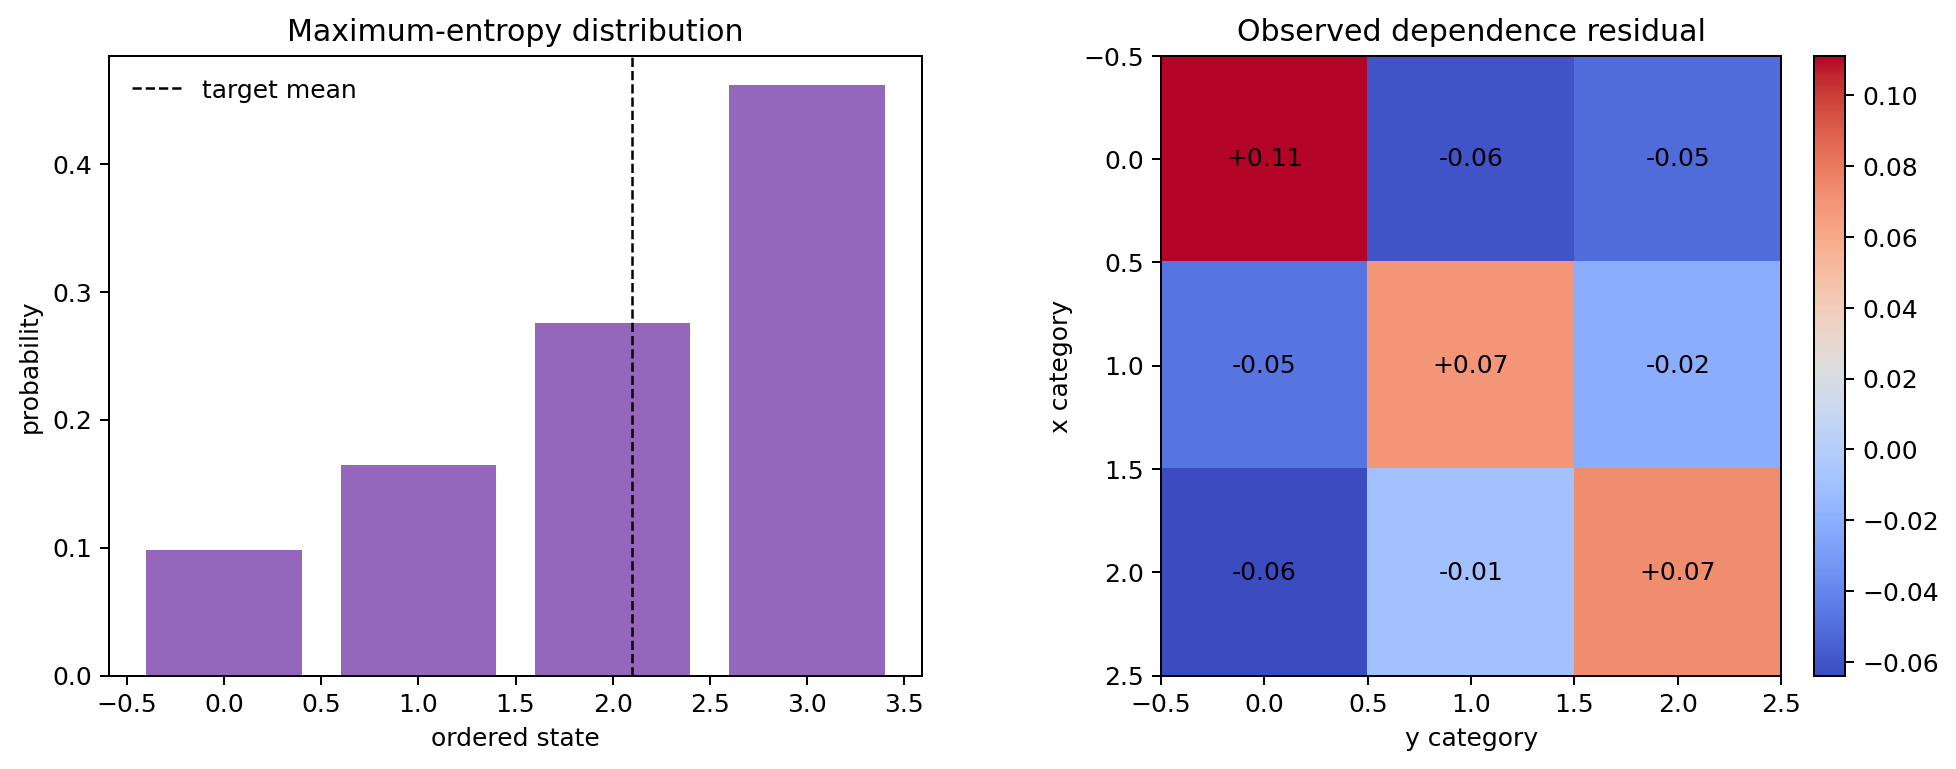

In [10]:
def maxent_on_ordered_states(states, target_mean):
    states = np.asarray(states, dtype=float)
    lo, hi = -50.0, 50.0
    for _ in range(160):
        mid = (lo + hi)/2
        w = np.exp(mid * states - np.max(mid * states))
        p = w / w.sum()
        if p @ states < target_mean:
            lo = mid
        else:
            hi = mid
    lam = (lo + hi)/2
    w = np.exp(lam * states - np.max(lam * states))
    p = w / w.sum()
    return lam, p

states_lab = np.arange(4)
target_mean_lab = 2.1
lambda_lab, p_lab = maxent_on_ordered_states(states_lab, target_mean_lab)
observed_counts = np.array([[18, 5, 4], [6, 16, 7], [3, 8, 13]], dtype=float)
observed_joint = observed_counts / observed_counts.sum()
independent_projection = np.outer(observed_joint.sum(axis=1), observed_joint.sum(axis=0))
mi_lab = kl(observed_joint.ravel(), independent_projection.ravel())

lab_summary = pd.DataFrame([
    {'quantity': 'maxent lambda', 'value': lambda_lab},
    {'quantity': 'target mean', 'value': target_mean_lab},
    {'quantity': 'achieved mean', 'value': float(p_lab @ states_lab)},
    {'quantity': 'maxent entropy', 'value': entropy(p_lab)},
    {'quantity': 'mutual information of observed table', 'value': mi_lab},
])
lab_path = TABLE_DIR / 'applied_lab_summary.csv'
lab_summary.to_csv(lab_path, index=False)
display(lab_summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].bar(states_lab, p_lab, color='#9467bd')
axes[0].set_title('Maximum-entropy distribution')
axes[0].set_xlabel('ordered state')
axes[0].set_ylabel('probability')
axes[0].axvline(target_mean_lab, color='black', ls='--', lw=1, label='target mean')
axes[0].legend(frameon=False)
resid = observed_joint - independent_projection
im = axes[1].imshow(resid, cmap='coolwarm')
axes[1].set_title('Observed dependence residual')
axes[1].set_xlabel('y category')
axes[1].set_ylabel('x category')
for (i, j), val in np.ndenumerate(resid):
    axes[1].text(j, i, f'{val:+.2f}', ha='center', va='center')
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
lab_fig_path = FIG_DIR / 'applied_lab_maxent_and_mi.png'
savefig(lab_fig_path)
display_artifact(lab_fig_path)

## 8. Sanity Checks

The checks intentionally test the identities that carry the chapter:

- softmax and log-odds invert each other on the simplex;
- the Bregman divergence of log-sum-exp agrees with KL in the chapter's order;
- the Fisher metric is the Hessian of the log-partition function;
- maximum entropy satisfies its moment constraint;
- mutual information vanishes after projection only when the joint distribution is already independent;
- every generated artifact exists and is nonempty.

In [11]:
artifact_paths = [
    simplex_path, simplex_html, translation_path, metric_path,
    gaussian_path, maxent_path, mi_path, mi_html, mi_table_path,
    lab_path, lab_fig_path,
]

p_round = np.array([0.31, 0.22, 0.47])
roundtrip_error = float(np.max(np.abs(softmax_from_theta(theta_from_simplex(p_round)) - p_round)))
kl_bregman_error = abs(kl(softmax_from_theta(th_b), softmax_from_theta(th_a)) - bregman_psi(th_a, th_b))
fisher_hessian_error = float(np.max(np.abs(G - H_fd)))
maxent_mean_error = abs(float(p_hat @ states) - target_mean)
mi_projection_marginal_error = float(max(np.max(abs(prod.sum(axis=1)-px)), np.max(abs(prod.sum(axis=0)-py))))
artifact_sizes = {str(path): path.stat().st_size for path in artifact_paths}
visual_artifact_sizes = {str(path): path.stat().st_size for path in artifact_paths if path.suffix.lower() in {'.png', '.html'}}

checks = {
    'artifact_count': len(artifact_paths),
    'roundtrip_simplex_probability_error': roundtrip_error,
    'kl_bregman_logsumexp_error': float(kl_bregman_error),
    'fisher_hessian_max_error': fisher_hessian_error,
    'max_entropy_mean_error': float(maxent_mean_error),
    'mutual_information_nats': float(mi),
    'mi_projection_marginal_error': mi_projection_marginal_error,
    'applied_lab_mean_error': abs(float(p_lab @ states_lab) - target_mean_lab),
    'applied_lab_mi_nats': float(mi_lab),
    'min_artifact_size_bytes': int(min(artifact_sizes.values())),
    'min_visual_artifact_size_bytes': int(min(visual_artifact_sizes.values())),
}

assert roundtrip_error < 1e-12
assert kl_bregman_error < 1e-12
assert fisher_hessian_error < 1e-6
assert maxent_mean_error < 1e-12
assert mi > 0
assert mi_projection_marginal_error < 1e-12
assert checks['applied_lab_mean_error'] < 1e-12
assert min(artifact_sizes.values()) > 0
assert min(visual_artifact_sizes.values()) > 1000

final_sanity_path = CHECK_DIR / 'final_sanity.json'
final_sanity_path.write_text(json.dumps(checks, indent=2), encoding='utf-8')
display_artifact(final_sanity_path)

{'artifact_count': 11,
 'roundtrip_simplex_probability_error': 5.551115123125783e-17,
 'kl_bregman_logsumexp_error': 2.220446049250313e-16,
 'fisher_hessian_max_error': 3.811782889329152e-09,
 'max_entropy_mean_error': 0.0,
 'mutual_information_nats': 0.2418592062046444,
 'mi_projection_marginal_error': 5.551115123125783e-17,
 'applied_lab_mean_error': 0.0,
 'applied_lab_mi_nats': 0.15456643654469907,
 'min_artifact_size_bytes': 67,
 'min_visual_artifact_size_bytes': 78596}

## Takeaways

1. An exponential family is not merely a convenient parametric form. Its log-partition function supplies a convex potential, its Hessian is Fisher information, and its gradient converts natural coordinates into expectation coordinates.
2. Mixture geometry is dual to exponential geometry. m-geodesics are straight in probabilities or moments; e-geodesics are straight in log-density coordinates.
3. The simplex is the cleanest laboratory because it is both an exponential family and a mixture family. That is why log-sum-exp and negative entropy appear as dual potentials in the same picture.
4. The Gaussian family shows that the same duality survives in continuous models: natural coordinates make the density log-linear in sufficient statistics, while expectation coordinates record moments.
5. Maximum entropy is a projection theorem. Under linear expectation constraints, the selected distribution is the e-projection of the uniform distribution and has exponential form.
6. Mutual information is also a projection theorem. It is the KL divergence from a joint distribution to its m-projection onto the e-flat family of independent distributions.
7. The chapter's practical moral is that statistical procedures often become simpler when we ask which coordinate system makes the relevant family flat.

## Standalone Synthesis

The chapter focus is: Exponential and mixture families, e-flat and m-flat structures, maximum entropy, mutual information, and maximum likelihood.

Key computational translations:

- natural parameters draw straight e-flat coordinates. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- expectation parameters draw straight m-flat coordinates. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- maximum entropy is a projection onto moment constraints. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- likelihood fitting is a divergence minimization problem. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.

How to read the visual sequence:

- Gaussian family in natural and expectation coordinates. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- discrete simplex with exponential-family and mixture-family slices. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- maximum-entropy projection onto a moment hyperplane. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- mutual-information surface over a small joint table. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.


## Course Standard Note

**Source span:** printed pages 31-50; PDF pages 48-67. The PDF is used only for source orientation, not as a required companion while reading this standalone notebook. The final_sanity evidence for this chapter is stored under `artifacts/chapter-02` using the chapter's local sanity JSON naming convention.


In [ ]:
from pathlib import Path

def _discover_book_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'AGENTS.md').exists() and (candidate / 'artifacts').exists():
            return candidate
    raise RuntimeError('Could not locate book root')

BOOK_ROOT = _discover_book_root(Path.cwd())
BOOK_ROOT
